<a href="https://colab.research.google.com/github/Vasan-404/Apple-leaf-disease/blob/main/Copy_of_Apple_Leaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:




from google.colab import files
import zipfile, os

uploaded = files.upload()

for filename in uploaded.keys():
    if filename.endswith(".zip"):
        with zipfile.ZipFile(filename, "r") as zip_ref:
            zip_ref.extractall("dataset")
        print(f"{filename} extracted to dataset/")


Saving archive (9).zip to archive (9).zip
archive (9).zip extracted to dataset/


In [ ]:
import cv2
import pandas as pd
from tqdm import tqdm

DATASET_DIR = "dataset/Apple_Disease_Dataset/train"   # ✅ IMPORTANT FIX
ANNOTATION_FILE = "annotations.csv"

image_paths = []
xmins, ymins, xmaxs, ymaxs, labels = [], [], [], [], []

for label in os.listdir(DATASET_DIR):
    label_dir = os.path.join(DATASET_DIR, label)
    if not os.path.isdir(label_dir):
        continue

    for fname in tqdm(os.listdir(label_dir), desc=f"Processing {label}"):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue

        fpath = os.path.join(label_dir, fname)
        image = cv2.imread(fpath)
        if image is None:
            print(f"Skipping unreadable file: {fpath}")
            continue

        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)

        # ✅ IMPORTANT: path stored relative to root_dir="dataset"
        rel_path = os.path.relpath(fpath, "dataset")

        image_paths.append(rel_path)
        xmins.append(x)
        ymins.append(y)
        xmaxs.append(x + w)
        ymaxs.append(y + h)
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "xmin": xmins, "ymin": ymins, "xmax": xmaxs, "ymax": ymaxs,
    "label": labels
})
df.to_csv(ANNOTATION_FILE, index=False)
print(f"\n✅ Annotations saved to '{ANNOTATION_FILE}' with {len(df)} entries.")

Processing Apple___healthy: 100%|██████████| 2008/2008 [00:04<00:00, 494.59it/s]



✅ Annotations saved to 'annotations.csv' with 7771 entries.


In [ ]:
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image

class LeafDetectionDataset(Dataset):
    def __init__(self, csv_file, root_dir, class_map, transforms=None):
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.class_map = class_map
        self.transforms = transforms

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        row = self.annotations.iloc[idx]
        img_path = os.path.join(self.root_dir, row["filename"])
        image = Image.open(img_path).convert("RGB")

        boxes = torch.tensor([[row["xmin"], row["ymin"], row["xmax"], row["ymax"]]], dtype=torch.float32)
        label = torch.tensor([self.class_map[row["label"]]], dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": label,
            "image_id": torch.tensor([idx])
        }

        if self.transforms:
            image = self.transforms(image)

        return image, target

def get_class_map(csv_file):
    df = pd.read_csv(csv_file)
    classes = sorted(df["label"].unique())
    return {cls: i + 1 for i, cls in enumerate(classes)}  # 0 is background

csv_file = "annotations.csv"
root_dir = "dataset"                     # ✅ IMPORTANT FIX
class_map = get_class_map(csv_file)
num_classes = len(class_map) + 1         # background + classes

transform = transforms.Compose([transforms.ToTensor()])

dataset = LeafDetectionDataset(csv_file, root_dir, class_map, transforms=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

print("✅ Classes:", class_map)
print(f"✅ Train size: {len(train_ds)}, Val size: {len(val_ds)}")

✅ Classes: {'Apple___Apple_scab': 1, 'Apple___Black_rot': 2, 'Apple___Cedar_apple_rust': 3, 'Apple___healthy': 4}
✅ Train size: 6216, Val size: 1555


In [ ]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print("✅ Device:", device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

num_epochs = 4

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for imgs, targets in train_loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    print(f"[Epoch {epoch+1}/{num_epochs}] Loss: {epoch_loss / max(1, len(train_loader)):.4f}")

torch.save(model.state_dict(), "fasterrcnn_apple_leaf.pth")
print("✅ Model saved as fasterrcnn_apple_leaf.pth")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 180MB/s]


✅ Device: cuda
[Epoch 1/4] Loss: 0.0570
[Epoch 2/4] Loss: 0.0312
[Epoch 3/4] Loss: 0.0274
[Epoch 4/4] Loss: 0.0240
✅ Model saved as fasterrcnn_apple_leaf.pth


In [ ]:
from torchvision.ops import box_iou

def evaluate(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    model.eval()
    total_images = 0
    correct_images = 0
    total_iou = 0
    iou_count = 0

    with torch.no_grad():
        for imgs, targets in data_loader:
            imgs = [img.to(device) for img in imgs]
            outputs = model(imgs)

            for pred, target in zip(outputs, targets):
                gt_boxes = target["boxes"].to(device)
                pred_boxes = pred["boxes"]
                pred_scores = pred["scores"]

                keep = pred_scores > score_threshold
                pred_boxes = pred_boxes[keep]

                total_images += 1
                if len(pred_boxes) == 0:
                    continue

                ious = box_iou(pred_boxes, gt_boxes)
                max_iou = ious.max().item()

                total_iou += max_iou
                iou_count += 1

                if max_iou >= iou_threshold:
                    correct_images += 1

    avg_iou = total_iou / iou_count if iou_count else 0
    accuracy = correct_images / total_images if total_images else 0

    print("\n✅ Evaluation Results:")
    print(f"Average IoU: {avg_iou:.4f}")
    print(f"Detection Accuracy (IoU ≥ {iou_threshold}): {accuracy * 100:.2f}%")

evaluate(model, val_loader, device)


✅ Evaluation Results:
Average IoU: 0.9393
Detection Accuracy (IoU ≥ 0.5): 99.04%


Saving 0c620ec5-11cf-4120-94ab-1311e99df147___FREC_Scab 3131.JPG to 0c620ec5-11cf-4120-94ab-1311e99df147___FREC_Scab 3131.JPG

🔍 Processing: 0c620ec5-11cf-4120-94ab-1311e99df147___FREC_Scab 3131.JPG
✅ Predicted Disease (best): Apple___Apple_scab  |  Confidence: 0.99


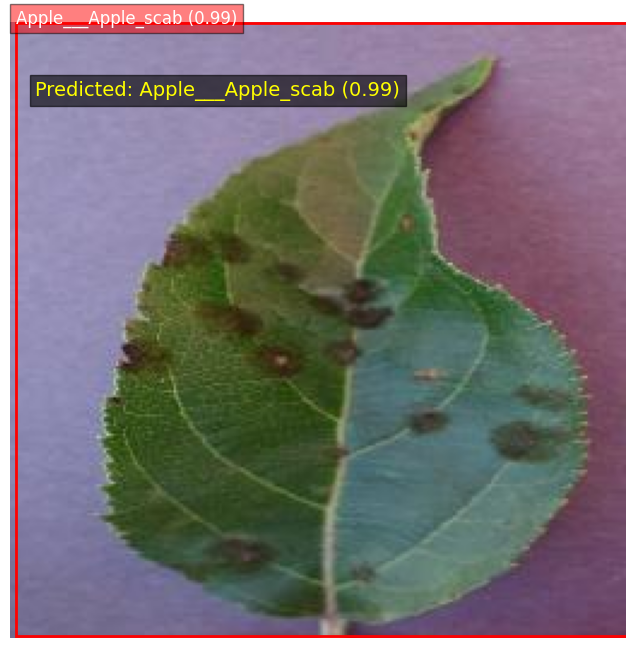

In [ ]:
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches

inv_class_map = {v: k for k, v in class_map.items()}
model.eval()

uploaded = files.upload()
for image_path in uploaded.keys():
    print(f"\n🔍 Processing: {image_path}")

    image = Image.open(image_path).convert("RGB")
    img_tensor = T.ToTensor()(image).to(device)

    with torch.no_grad():
        output = model([img_tensor])[0]

    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(img_np)

    found = False
    best_label = None
    best_score = 0.0

    for box, score, label in zip(output["boxes"], output["scores"], output["labels"]):
        if float(score.item()) < 0.5:
            continue

        found = True
        box = box.cpu().numpy()
        score_val = float(score.item())
        label_id = int(label.item())
        name = inv_class_map.get(label_id, f"Class {label_id}")

        if score_val > best_score:
            best_score = score_val
            best_label = name

        rect = patches.Rectangle(
            (box[0], box[1]),
            box[2] - box[0],
            box[3] - box[1],
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)

        ax.text(
            box[0], max(0, box[1] - 10),
            f"{name} ({score_val:.2f})",
            fontsize=12, color="white",
            bbox=dict(facecolor="red", alpha=0.5)
        )

    if not found:
        print("❌ No disease detected with confidence ≥ 0.5")
    else:
        print(f"✅ Predicted Disease (best): {best_label}  |  Confidence: {best_score:.2f}")
        ax.text(10, 30, f"Predicted: {best_label} ({best_score:.2f})",
                fontsize=14, color="yellow",
                bbox=dict(facecolor="black", alpha=0.6))

    plt.axis("off")
    plt.show()

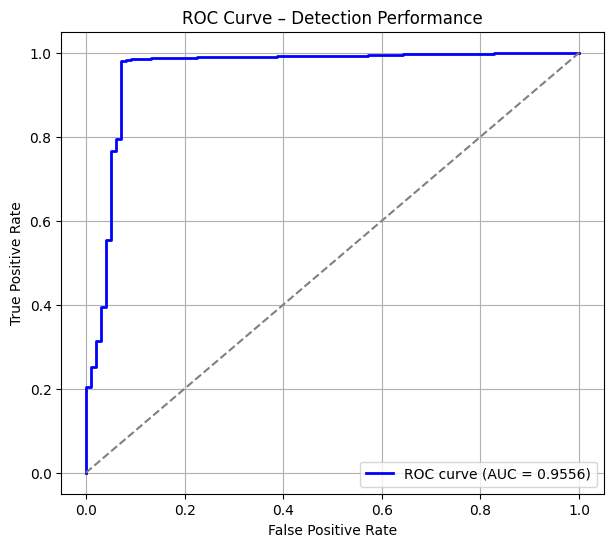

✅ ROC-AUC Score: 0.9556


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from torchvision.ops import box_iou

y_true = []
y_scores = []

model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):

            gt_box = target["boxes"].to(device)       # shape [1,4]
            gt_label = int(target["labels"][0].item())

            pred_boxes = output["boxes"].to(device)
            pred_scores = output["scores"].to(device)
            pred_labels = output["labels"].to(device)

            if pred_boxes.shape[0] == 0:
                y_true.append(0)
                y_scores.append(0.0)
                continue

            # Compute IoU of all predicted boxes with GT box
            ious = box_iou(pred_boxes, gt_box)   # shape [num_preds, 1]
            ious = ious.squeeze(1)

            # Select the box with maximum IoU, not maximum confidence
            best_iou_idx = torch.argmax(ious).item()

            best_iou = float(ious[best_iou_idx].item())
            best_score = float(pred_scores[best_iou_idx].item())
            best_label = int(pred_labels[best_iou_idx].item())

            is_correct = (best_label == gt_label) and (best_iou >= 0.5)

            y_true.append(1 if is_correct else 0)
            y_scores.append(best_score)

# Check if both classes exist
if len(set(y_true)) < 2:
    print("ROC cannot be computed properly because only one class is present in y_true.")
else:
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve – Detection Performance")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    print(f"✅ ROC-AUC Score: {roc_auc:.4f}")

Validation Accuracy: 98.52%


/tmp/ipykernel_3352/2760412878.py:71: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)


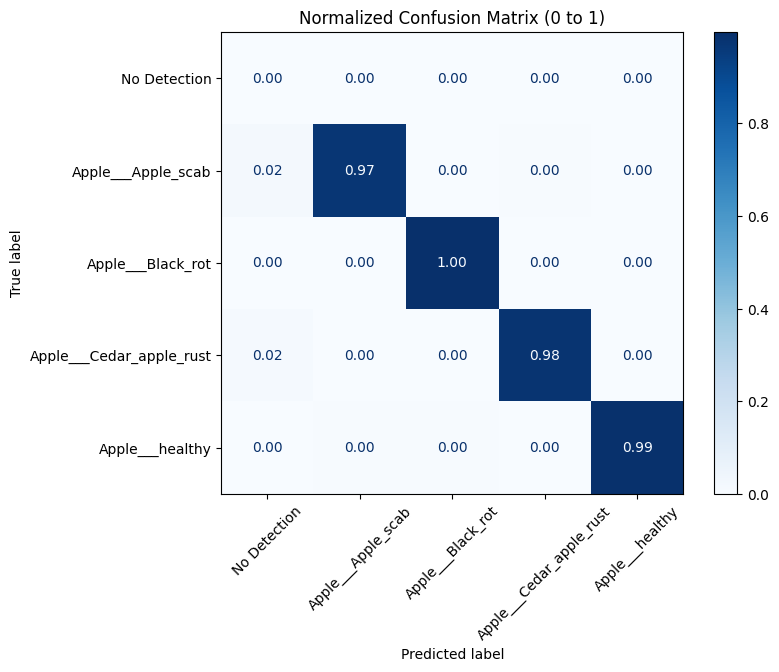

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from torchvision.ops import box_iou

model.eval()

all_true = []
all_pred = []

# class name mapping
id_to_name = {v: k for k, v in class_map.items()}

# include 0 for no detection
labels_with_bg = [0] + list(range(1, num_classes))
display_labels = ["No Detection"] + [id_to_name[i] for i in range(1, num_classes)]

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):
            gt_boxes = target["boxes"].to(device)
            gt_labels = target["labels"].to(device)

            pred_boxes = output["boxes"].to(device)
            pred_labels = output["labels"].to(device)
            pred_scores = output["scores"].to(device)

            # confidence filter
            score_threshold = 0.5
            keep = pred_scores >= score_threshold
            pred_boxes = pred_boxes[keep]
            pred_labels = pred_labels[keep]

            # if no predictions remain
            if pred_boxes.shape[0] == 0:
                for gt_lab in gt_labels:
                    all_true.append(int(gt_lab.item()))
                    all_pred.append(0)
                continue

            # IoU matrix
            ious = box_iou(pred_boxes, gt_boxes)

            for j in range(gt_boxes.shape[0]):
                gt_lab = int(gt_labels[j].item())

                best_iou, best_idx = torch.max(ious[:, j], dim=0)
                best_iou = float(best_iou.item())
                best_idx = int(best_idx.item())

                if best_iou >= 0.5:
                    pred_lab = int(pred_labels[best_idx].item())
                else:
                    pred_lab = 0  # no detection

                all_true.append(gt_lab)
                all_pred.append(pred_lab)

# accuracy
acc = accuracy_score(all_true, all_pred)
print(f"Validation Accuracy: {acc * 100:.2f}%")

# raw confusion matrix
cm = confusion_matrix(all_true, all_pred, labels=labels_with_bg)

# normalize row-wise to 0–1
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

# replace NaN rows if any class has no samples
cm_normalized = np.nan_to_num(cm_normalized)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=display_labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45, values_format=".2f")
plt.title("Normalized Confusion Matrix (0 to 1)")
plt.show()